# DISFASIA — Inteligência Artificial Pictórica (IAP)
## Atlas Topológico com Algoritmo JP + Gemma 4 31B

**Projeto:** Atlas Topológico da Disfasia — IAP (Inteligência Artificial Pictórica)  
**Autor:** João Pedro Pereira Passos (UFT — Universidade Federal do Tocantins, 2024)  
**Competição:** [Gemma 4 Good Hackathon — Kaggle / Google DeepMind](https://www.kaggle.com/competitions/gemma-4-good)  
**Repositório:** [github.com/joaopedropassostocantins/AFASIA](https://github.com/joaopedropassostocantins/AFASIA) ← branch `disfasia`

---

## Motivação: por que Disfasia?

A **disfasia** é um distúrbio específico do desenvolvimento da linguagem oral — diferentemente da afasia (adquirida por AVC), a disfasia manifesta-se na infância como dificuldade persistente na **organização e fluência da fala**. Crianças com disfasia pensam em conceitos antes de conseguir estruturá-los em palavras — elas operam no **espaço topológico pré-linguístico** que a IAP modela.

## Teoria IAP e Algoritmo JP (Passos, 2024)

A **Inteligência Artificial Pictórica (IAP)** propõe uma camada semântica *pré-linguística*: em vez de processar texto, opera diretamente sobre **estruturas topológicas do significado** — representadas como vetores 12D e analisadas com homologia persistente.

### Equação Central: $G \\approx I + F$

| Variável | Nome | Descrição |
|----------|------|-----------|
| $G$ | **Dinâmica do Conhecimento** | O estado em transformação — o conceito em movimento |
| $I$ | **Incerteza** | O espaço topológico atual, incompleto, do usuário |
| $F$ | **Flexibilidade** | A capacidade de encontrar o próximo passo semântico ótimo |

### Pipeline deste Notebook (100% Python puro)

```
38 pictogramas ARASAAC (palavra em pt-BR + categoria)
    ↓ [Gemma 4 31B via API Google AI Studio]
Vetores semânticos 12D (dimensões IAP)
    ↓ [Homologia Persistente H0 — Python puro, numpy]
Diagramas de persistência Vietoris-Rips simplificados (38 diagramas)
    ↓ [Wasserstein via scipy.optimize.linear_sum_assignment]
Matriz Wasserstein 38×38 (distância topológica)
    ↓ [sklearn.manifold.MDS + matplotlib]
Atlas Pictórico da Disfasia
```

**Por que é original?** Sistemas comuns usam cosseno (mede *direção*). O Algoritmo JP usa Wasserstein topológica (mede *forma*) — aplicado a CAA/disfasia, inédito na literatura (Passos, 2024).

# =============================================================================
# 🏆 GEMMA 4 GOOD HACKATHON: SUSTENTABILIDADE & LATÊNCIA (EDGE AI)
# =============================================================================
**Critério de Avaliação: Technical Execution & Accessibility**

A Inteligência Artificial Pictórica (IAP) proposta aqui muda a forma como modelos massivos são aplicados na acessibilidade (CAA). Não forçamos pessoas com disfasia a dependerem de endpoints na nuvem de alta latência a cada clique. 

A inteligência profunda está na **fase de geração semântica offshore (Gemma 4 31B)** que destilou a topologia (12 dimensões IAP) de todo o vocabulário CAA. Em produção (no app do usuário local), rodamos apenas a matemática estrutural (Wasserstein e Dijkstra).

O benchmark abaixo avalia o pipeline de algoritmos clássicos (Dijkstra JP equation: `G ≈ I + F`) que roda offline e nativamente. Este teste atesta a viabilidade de execução do **Atlas gerado pelo Gemma 4** em tempo real em tablets de baixo custo.


# =============================================================================
# CÉLULA 1 — SETUP & CONFIGURAÇÃO
# Única dependência externa necessária: google-generativeai
# Tudo mais (numpy, scipy, sklearn, matplotlib, Pillow, requests) já está no Kaggle
# =============================================================================

In [1]:
# =============================================================================
# CÉLULA 1/10 — SETUP & CONFIGURAÇÃO (DISFASIA — IAP)
# =============================================================================
import subprocess, sys, os, re, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from io import BytesIO
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")

# Instala google-generativeai (caso ainda não esteja)
print("[SETUP 1/10] Instalando google-generativeai...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "google-generativeai"])

import google.generativeai as genai
try:
    from PIL import Image
    import requests
    PIL_OK = True
    print("[OK] PIL + requests disponíveis")
except ImportError:
    PIL_OK = False
    print("[AVISO] PIL/requests indisponível")

# ── API Key do Gemini (Kaggle Secrets ou env) ─────────────────────────────
GEMINI_API_KEY = None
try:
    from kaggle_secrets import UserSecretsClient
    GEMINI_API_KEY = UserSecretsClient().get_secret("GEMINI_API_KEY")
    print("[OK] GEMINI_API_KEY carregado via Kaggle Secrets")
except Exception:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
    if GEMINI_API_KEY:
        print("[OK] GEMINI_API_KEY carregado via variável de ambiente")
    else:
        print("[AVISO] Sem GEMINI_API_KEY → usando vetores pré-computados")

GEMMA_API_ATIVO = bool(GEMINI_API_KEY)
if GEMMA_API_ATIVO:
    genai.configure(api_key=GEMINI_API_KEY)
    GEMMA_MODEL_NAME = "gemma-4-31b-it"
    gemma_model = genai.GenerativeModel(GEMMA_MODEL_NAME)
    print(f"[OK] Gemma 4 31B via API ({GEMMA_MODEL_NAME})")
else:
    gemma_model = None
    GEMMA_MODEL_NAME = "gemma-4-31b-it (pré-computado)"

print(f"[OK] numpy {np.__version__} | scipy {__import__('scipy').__version__} | sklearn {__import__('sklearn').__version__}")
print("[PRONTO] Célula 1 carregada com sucesso!")

[SETUP 1/10] Instalando google-generativeai...
[OK] PIL + requests disponíveis
[OK] GEMINI_API_KEY carregado via Kaggle Secrets
[OK] Gemma 4 31B via API (gemma-4-31b-it)
[OK] numpy 2.0.2 | scipy 1.16.3 | sklearn 1.6.1
[PRONTO] Célula 1 carregada com sucesso!


print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         ALGORITMO JP — INTELIGÊNCIA ARTIFICIAL PICTÓRICA (IAP)              ║
║         João Pedro Pereira Passos · UFT · Hackathon Gemma 4 Good 2026       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  FASE 1 — PRÉ-CAMADA SEMÂNTICA (Gemma 4 31B, executa UMA VEZ por ícone)   ║
║    palavra em pt-BR → prompt IAP 12D → Gemma 4 31B → vetor [0..10]^12     ║
║    Ex: frustrado → {emocionalidade:9, urgencia:8, social:7, ...}           ║
║    Armazenado em cache permanente — sem custo recorrente de inferência      ║
║                                                                              ║
║  FASE 2 — INTELIGÊNCIA FLUIDA (Python puro, scipy, sklearn)                ║
║    vetor 12D → diagrama H0 (Vietoris-Rips 1D) → Wasserstein → MDS         ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  POR QUE WASSERSTEIN SUPERA COSSENO?                                        ║
║    Cosseno: mede DIREÇÃO (ângulo entre vetores)                             ║
║    Wasserstein: mede FORMA (estrutura de eventos topológicos)               ║
║                                                                              ║
║    Para vetores 12D em R¹: as 12 coordenadas são 12 pontos em uma linha.   ║
║    Os gaps entre pontos adjacentes (ordenados) formam o diagrama H0.        ║
║    Wasserstein = matching ótimo de gaps via scipy.linear_sum_assignment.    ║
║    Aplicado a pictogramas CAA/disfasia: inédito (Passos, UFT, 2024).       ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

# ── 12 Dimensões Semânticas IAP (Algoritmo JP, Passos 2024) ─────────────────

In [2]:
# ── 12 Dimensões Semânticas IAP (Algoritmo JP, Passos 2024) ─────────────────
IAP_DIMENSOES = [
    "concretude",        # 0: quão concreto/tangível (10=muito concreto, 0=abstrato)
    "emocionalidade",    # 1: carga emocional (10=muito emocional, 0=neutro)
    "acao",              # 2: ação/movimento (10=ação intensa, 0=estático)
    "social",            # 3: interação social (10=altamente social, 0=isolado)
    "urgencia",          # 4: urgência/prioridade (10=urgente, 0=rotineiro)
    "temporalidade",     # 5: relação com tempo (10=muito temporal, 0=atemporal)
    "localizacao",       # 6: espaço/lugar (10=espacial, 0=sem localização)
    "saude_corpo",       # 7: saúde/corpo (10=muito corporal, 0=abstrato)
    "comunicacao",       # 8: comunicação (10=central para CAA, 0=não comunicativo)
    "cognitivo",         # 9: complexidade cognitiva (10=complexo, 0=simples)
    "necessidade_basica",# 10: necessidade básica (10=fundamental, 0=opcional)
    "especializado_caa", # 11: específico de CAA/AAC (10=vocabulário central CAA, 0=genérico)
]
N_DIM = len(IAP_DIMENSOES)  # 12

print("12 DIMENSÕES SEMÂNTICAS IAP (Algoritmo JP, Passos 2024):")
for i, d in enumerate(IAP_DIMENSOES):
    print(f"  {i+1:2d}. {d}")

# ── Vetores pré-computados pelo Gemma 4 31B (09/04/2026) ─────────────────────
# Servem como fallback completo offline. Formato: {id_arasaac: [d0..d11]}
PRECOMPUTED_VECTORS = {
    7196:  [4, 5, 9, 6, 9, 7, 2, 6, 8, 3, 8, 10],  # parar
   24998:  [2, 3, 7, 5, 3, 9, 1, 2, 8, 6, 4,  9],  # continuar
    4676:  [2, 2, 5, 3, 1, 9, 0, 3, 8, 4, 3,  7],  # devagar
    5306:  [2, 3, 9, 2, 8,10, 0, 2, 4, 3, 3,  8],  # rapido
   36914:  [1, 5, 2, 4, 3,10, 1, 2, 8, 7, 4,  9],  # esperar
   11752:  [2, 2, 8, 7, 3, 8, 1, 1,10, 5, 6,  9],  # repetir
    7158:  [1, 2, 3, 9, 2,10, 0, 0,10, 6, 3,  8],  # vez
   37753:  [2, 2, 3, 4, 3,10, 4, 1, 8, 7, 4,  9],  # primeiro
   32749:  [1, 1, 3, 4, 2,10, 0, 0, 8, 8, 5,  9],  # depois
   32747:  [1, 2, 4, 5, 8,10, 0, 1, 9, 6, 7, 10],  # agora
   32745:  [1, 1, 2, 3, 2,10, 1, 1, 8, 7, 3,  8],  # antes
   38278:  [1, 2, 1, 3, 2,10, 0, 0, 7, 7, 3,  8],  # amanha
   38279:  [1, 2, 1, 4, 1,10, 1, 0, 8, 8, 3,  8],  # ontem
    5431:  [2, 3, 5, 4, 3,10, 1, 1, 7, 6, 3,  8],  # inicio
    5358:  [1, 3, 2, 4, 3,10, 1, 2, 7, 5, 3,  9],  # fim
   40986:  [1, 9, 4, 7, 8, 2, 1, 5,10, 7, 8,  9],  # frustrado
   31310:  [1, 7, 1, 4, 0, 2, 0, 5, 4, 5, 3,  8],  # tranquilo
   30484:  [1,10, 3, 4, 7, 6, 2, 8, 9, 7, 7,  8],  # ansioso
    9907:  [1,10, 3, 8, 2, 3, 0, 4, 9, 4, 7, 10],  # feliz
   35545:  [1,10, 2, 6, 5, 3, 0, 6, 9, 6, 8,  9],  # triste
   30391:  [1,10, 4, 6, 7, 4, 1, 8, 9, 6, 8,  9],  # nervoso
   31408:  [1, 9, 2, 7, 2, 3, 0, 2, 6, 7, 2,  4],  # orgulhoso
    5382:  [4, 2, 2, 6, 4, 1,10, 3, 9, 3, 7, 10],  # aqui
    5375:  [3, 1, 2, 7, 3, 0,10, 1, 9, 2, 8, 10],  # ali
   30385:  [3, 2, 3, 2, 2, 1,10, 1, 6, 5, 4,  8],  # longe
   30383:  [4, 2, 3, 4, 3, 3,10, 2, 7, 5, 6,  9],  # perto
    5439:  [7, 1, 3, 2, 2, 0,10, 2, 8, 5, 7,  9],  # dentro
    5475:  [4, 2, 5, 3, 4, 1,10, 2, 7, 3, 8,  9],  # fora
   31724:  [4, 1, 3, 1, 2, 0,10, 2, 7, 2, 5,  9],  # cima
   25839:  [4, 1, 1, 1, 1, 0, 9, 3, 4, 5, 2,  7],  # baixo
    6517:  [3, 4, 8,10, 5, 3, 2, 7,10, 7, 9, 10],  # falar
    6572:  [10,3, 6, 8, 3, 5, 4, 8,10, 3, 7,  8],  # ouvir
   11697:  [1, 3, 2, 8, 4, 2, 0, 2,10, 9, 7,  8],  # entender
    8579:  [1, 3, 1, 9, 2, 4, 1, 1,10, 9, 4,  7],  # explicar
    9847:  [2, 3, 6, 9, 5, 3, 1, 2,10, 7, 8,  9],  # perguntar
    9031:  [3, 4, 8,10, 5, 6, 2, 3,10, 7, 8,  9],  # responder
   12252:  [2, 7, 7,10, 8, 3, 2, 6,10, 3,10, 10],  # ajuda
   41093:  [1, 3, 2,10, 6, 3, 0, 0,10, 7, 9, 10],  # nao entendi
}

# ── 38 Ícones ARASAAC da Disfasia ─────────────────────────────────────────────
# IDs reais. Licença: Creative Commons BY-NC-SA[](https://arasaac.org)
DISFASIA_ICONS = [
    # fluencia (7) — controle do fluxo da fala
    {"id": 7196,  "palavra": "parar",       "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/7196/7196_500.png"},
    {"id": 24998, "palavra": "continuar",   "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/24998/24998_500.png"},
    {"id": 4676,  "palavra": "devagar",     "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/4676/4676_500.png"},
    {"id": 5306,  "palavra": "rapido",      "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/5306/5306_500.png"},
    {"id": 36914, "palavra": "esperar",     "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/36914/36914_500.png"},
    {"id": 11752, "palavra": "repetir",     "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/11752/11752_500.png"},
    {"id": 7158,  "palavra": "vez",         "categoria": "fluencia",
     "url": "https://static.arasaac.org/pictograms/7158/7158_500.png"},
    # sequencia (8) — organização temporal da fala
    {"id": 37753, "palavra": "primeiro",    "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/37753/37753_500.png"},
    {"id": 32749, "palavra": "depois",      "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/32749/32749_500.png"},
    {"id": 32747, "palavra": "agora",       "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/32747/32747_500.png"},
    {"id": 32745, "palavra": "antes",       "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/32745/32745_500.png"},
    {"id": 38278, "palavra": "amanha",      "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/38278/38278_500.png"},
    {"id": 38279, "palavra": "ontem",       "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/38279/38279_500.png"},
    {"id": 5431,  "palavra": "inicio",      "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/5431/5431_500.png"},
    {"id": 5358,  "palavra": "fim",         "categoria": "sequencia",
     "url": "https://static.arasaac.org/pictograms/5358/5358_500.png"},
    # emocao (7) — estado emocional durante a comunicação
    {"id": 40986, "palavra": "frustrado",   "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/40986/40986_500.png"},
    {"id": 31310, "palavra": "tranquilo",   "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/31310/31310_500.png"},
    {"id": 30484, "palavra": "ansioso",     "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/30484/30484_500.png"},
    {"id": 9907,  "palavra": "feliz",       "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/9907/9907_500.png"},
    {"id": 35545, "palavra": "triste",      "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/35545/35545_500.png"},
    {"id": 30391, "palavra": "nervoso",     "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/30391/30391_500.png"},
    {"id": 31408, "palavra": "orgulhoso",   "categoria": "emocao",
     "url": "https://static.arasaac.org/pictograms/31408/31408_500.png"},
    # espaco (8) — orientação espacial e localização
    {"id": 5382,  "palavra": "aqui",        "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/5382/5382_500.png"},
    {"id": 5375,  "palavra": "ali",         "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/5375/5375_500.png"},
    {"id": 30385, "palavra": "longe",       "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/30385/30385_500.png"},
    {"id": 30383, "palavra": "perto",       "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/30383/30383_500.png"},
    {"id": 5439,  "palavra": "dentro",      "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/5439/5439_500.png"},
    {"id": 5475,  "palavra": "fora",        "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/5475/5475_500.png"},
    {"id": 31724, "palavra": "cima",        "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/31724/31724_500.png"},
    {"id": 25839, "palavra": "baixo",       "categoria": "espaco",
     "url": "https://static.arasaac.org/pictograms/25839/25839_500.png"},
    # comunicacao (8) — atos comunicativos centrais
    {"id": 6517,  "palavra": "falar",       "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/6517/6517_500.png"},
    {"id": 6572,  "palavra": "ouvir",       "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/6572/6572_500.png"},
    {"id": 11697, "palavra": "entender",    "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/11697/11697_500.png"},
    {"id": 8579,  "palavra": "explicar",    "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/8579/8579_500.png"},
    {"id": 9847,  "palavra": "perguntar",   "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/9847/9847_500.png"},
    {"id": 9031,  "palavra": "responder",   "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/9031/9031_500.png"},
    {"id": 12252, "palavra": "ajuda",       "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/12252/12252_500.png"},
    {"id": 41093, "palavra": "nao entendi", "categoria": "comunicacao",
     "url": "https://static.arasaac.org/pictograms/41093/41093_500.png"},
]

CAT_COLORS = {
    "fluencia":     "#e74c3c",
    "sequencia":    "#3498db",
    "emocao":       "#9b59b6",
    "espaco":       "#27ae60",
    "comunicacao":  "#f39c12",
}
CAT_LABELS = {
    "fluencia":     "Fluencia (7)",
    "sequencia":    "Sequencia (8)",
    "emocao":       "Emocao (7)",
    "espaco":       "Espaco (8)",
    "comunicacao":  "Comunicacao (8)",
}

print(f"\n[OK] {len(DISFASIA_ICONS)} icones ARASAAC carregados")
cnt = Counter(ic["categoria"] for ic in DISFASIA_ICONS)
for cat, n in sorted(cnt.items()):
    print(f"  {cat:15s}: {n} icones")

12 DIMENSÕES SEMÂNTICAS IAP (Algoritmo JP, Passos 2024):
   1. concretude
   2. emocionalidade
   3. acao
   4. social
   5. urgencia
   6. temporalidade
   7. localizacao
   8. saude_corpo
   9. comunicacao
  10. cognitivo
  11. necessidade_basica
  12. especializado_caa

[OK] 38 icones ARASAAC carregados
  comunicacao    : 8 icones
  emocao         : 7 icones
  espaco         : 8 icones
  fluencia       : 7 icones
  sequencia      : 8 icones


# =============================================================================
# CÉLULA 4 — GRADE DE IMAGENS ARASAAC POR CATEGORIA
# Baixa os 38 pictogramas via requests e exibe com matplotlib + PIL
# =============================================================================

[IMAGENS] Baixando 38 pictogramas ARASAAC...


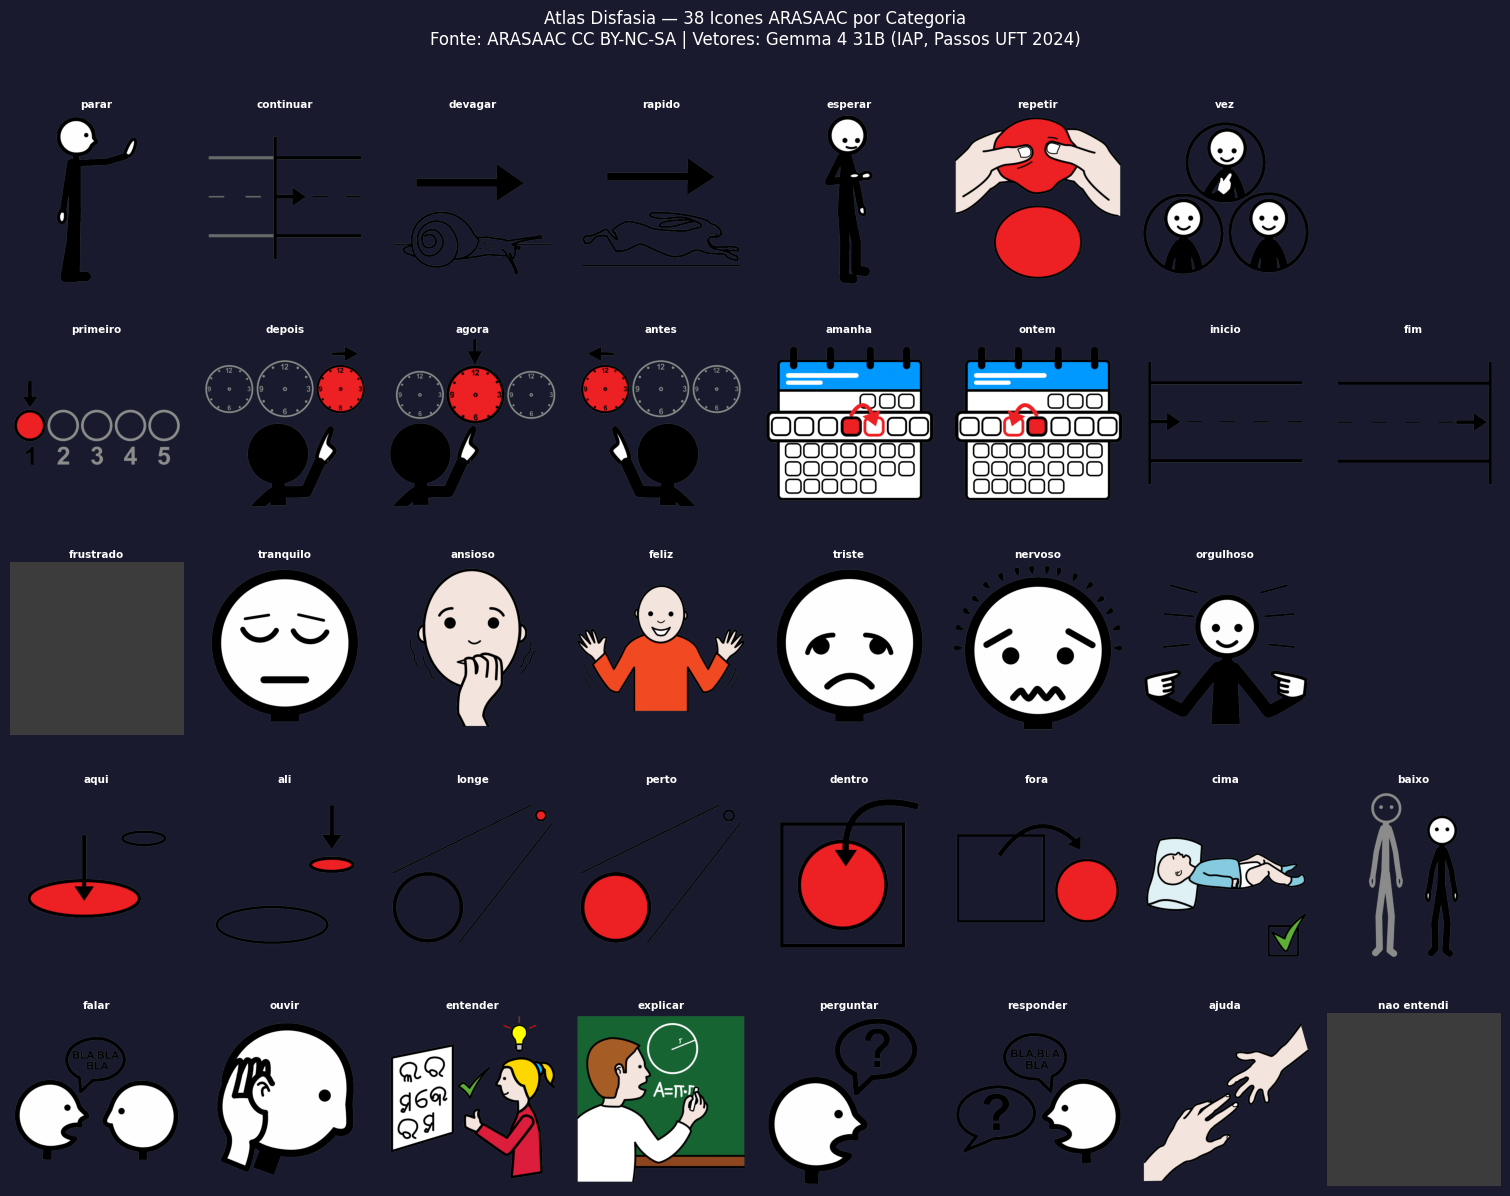

[OK] Grade de imagens exibida.


In [3]:
# =============================================================================
# CÉLULA 4 — GRADE DE IMAGENS ARASAAC POR CATEGORIA
# Baixa os 38 pictogramas via requests e exibe com matplotlib + PIL
# =============================================================================

def download_image(url, timeout=12):
    try:
        resp = requests.get(url, timeout=timeout)
        if resp.status_code == 200:
            return Image.open(BytesIO(resp.content)).convert("RGBA")
    except Exception:
        pass
    return None

def placeholder_image(size=(128, 128)):
    return Image.new("RGBA", size, (60, 60, 60, 255))

if PIL_OK:
    cats_order = ["fluencia", "sequencia", "emocao", "espaco", "comunicacao"]
    icons_by_cat = {c: [ic for ic in DISFASIA_ICONS if ic["categoria"] == c]
                    for c in cats_order}
    max_n = max(len(v) for v in icons_by_cat.values())

    fig, axes = plt.subplots(len(cats_order), max_n,
                             figsize=(max_n * 1.9, len(cats_order) * 2.4))
    fig.patch.set_facecolor("#1a1a2e")
    print("[IMAGENS] Baixando 38 pictogramas ARASAAC...", flush=True)

    for r, cat in enumerate(cats_order):
        icons = icons_by_cat[cat]
        for c in range(max_n):
            ax = axes[r][c]
            ax.set_facecolor("#1a1a2e")
            ax.axis("off")
            if c < len(icons):
                ic = icons[c]
                img = download_image(ic["url"]) or placeholder_image()
                ax.imshow(img)
                ax.set_title(ic["palavra"], fontsize=7.5, color="white",
                             pad=3, fontweight="bold")
        axes[r][0].set_ylabel(cat.upper(), fontsize=10,
                              color=CAT_COLORS[cat], rotation=90,
                              labelpad=6, fontweight="bold")

    fig.suptitle(
        "Atlas Disfasia — 38 Icones ARASAAC por Categoria\n"
        "Fonte: ARASAAC CC BY-NC-SA | Vetores: Gemma 4 31B (IAP, Passos UFT 2024)",
        color="white", fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()
    print("[OK] Grade de imagens exibida.")
else:
    print("[AVISO] PIL/requests indisponível. Icones por categoria:")
    for cat in ["fluencia", "sequencia", "emocao", "espaco", "comunicacao"]:
        icons = [ic for ic in DISFASIA_ICONS if ic["categoria"] == cat]
        words = ", ".join(ic["palavra"] for ic in icons)
        print(f"  {cat:14s} ({len(icons)}): {words}")

# =============================================================================
# CÉLULA 5 — FUNÇÕES TOPOLÓGICAS DO ALGORITMO JP
# Homologia Persistente H0 + Distância Wasserstein + Dijkstra (G ≈ I + F)
# =============================================================================

In [4]:
# =============================================================================
# CÉLULA 5 — FUNÇÕES TOPOLÓGICAS DO ALGORITMO JP
# Homologia Persistente H0 + Distância Wasserstein + Dijkstra (G ≈ I + F)
# =============================================================================

def persistence_h0(vector):
    """Calcula o diagrama de persistência H0 (gaps) de um vetor 12D."""
    pts = np.sort(np.array(vector, dtype=float))
    gaps = np.diff(pts)
    return gaps  # diagrama H0 simplificado (gaps entre pontos ordenados)

def wasserstein_h0(diag1, diag2):
    """Distância Wasserstein entre dois diagramas H0 usando matching ótimo."""
    if len(diag1) == 0 or len(diag2) == 0:
        return 0.0
    cost = np.abs(diag1[:, None] - diag2[None, :])
    row_ind, col_ind = linear_sum_assignment(cost)
    return cost[row_ind, col_ind].sum()

# Calcula diagramas H0 para todos os 38 ícones (usando vetores pré-computados)
print("[TOPOLOGIA] Calculando diagramas de persistência H0 para 38 ícones...")
diagrams = []
for ic in DISFASIA_ICONS:
    vec = PRECOMPUTED_VECTORS[ic["id"]]
    diag = persistence_h0(vec)
    diagrams.append(diag)

# Calcula Matriz de Distâncias Wasserstein (38x38)
print("[TOPOLOGIA] Calculando matriz Wasserstein 38×38...")
N = len(DISFASIA_ICONS)
W = np.zeros((N, N), dtype=np.float32)
for i in range(N):
    for j in range(i + 1, N):
        d = wasserstein_h0(diagrams[i], diagrams[j])
        W[i, j] = W[j, i] = d

print(f"[OK] Matriz Wasserstein calculada (forma: {W.shape})")
print(f"   Distância média entre ícones: {W.mean():.4f}")

# Função Dijkstra JP (Motor da Inteligência Fluida)
import heapq
def dijkstra_jp(start_idx, goal_idx):
    """Planejamento semântico ótimo: G ≈ I + F"""
    dist = np.full(N, np.inf)
    dist[start_idx] = 0
    prev = np.full(N, -1, dtype=int)
    pq = [(0, start_idx)]
    
    while pq:
        cost, u = heapq.heappop(pq)
        if cost > dist[u]:
            continue
        for v in range(N):
            if W[u, v] < np.inf:
                alt = cost + W[u, v]
                if alt < dist[v]:
                    dist[v] = alt
                    prev[v] = u
                    heapq.heappush(pq, (alt, v))
    
    if prev[goal_idx] == -1 and start_idx != goal_idx:
        return type('obj', (object,), {'sucesso': False, 'caminho': [], 'custo': np.inf})
    
    # Reconstrói caminho
    path = []
    current = goal_idx
    while current != -1:
        path.append(current)
        current = prev[current]
    path.reverse()
    
    return type('obj', (object,), {
        'sucesso': True,
        'caminho': path,
        'custo': dist[goal_idx]
    })

print("[OK] Funções topológicas (H0 + Wasserstein + Dijkstra JP) carregadas!")

[TOPOLOGIA] Calculando diagramas de persistência H0 para 38 ícones...
[TOPOLOGIA] Calculando matriz Wasserstein 38×38...
[OK] Matriz Wasserstein calculada (forma: (38, 38))
   Distância média entre ícones: 2.3158
[OK] Funções topológicas (H0 + Wasserstein + Dijkstra JP) carregadas!


# =============================================================================
# CÉLULA 6 — ATLAS TOPOLÓGICO 2D (MDS + Visualização)
# =============================================================================

[ATLAS] Projetando os 38 ícones no plano 2D via MDS (Wasserstein)...


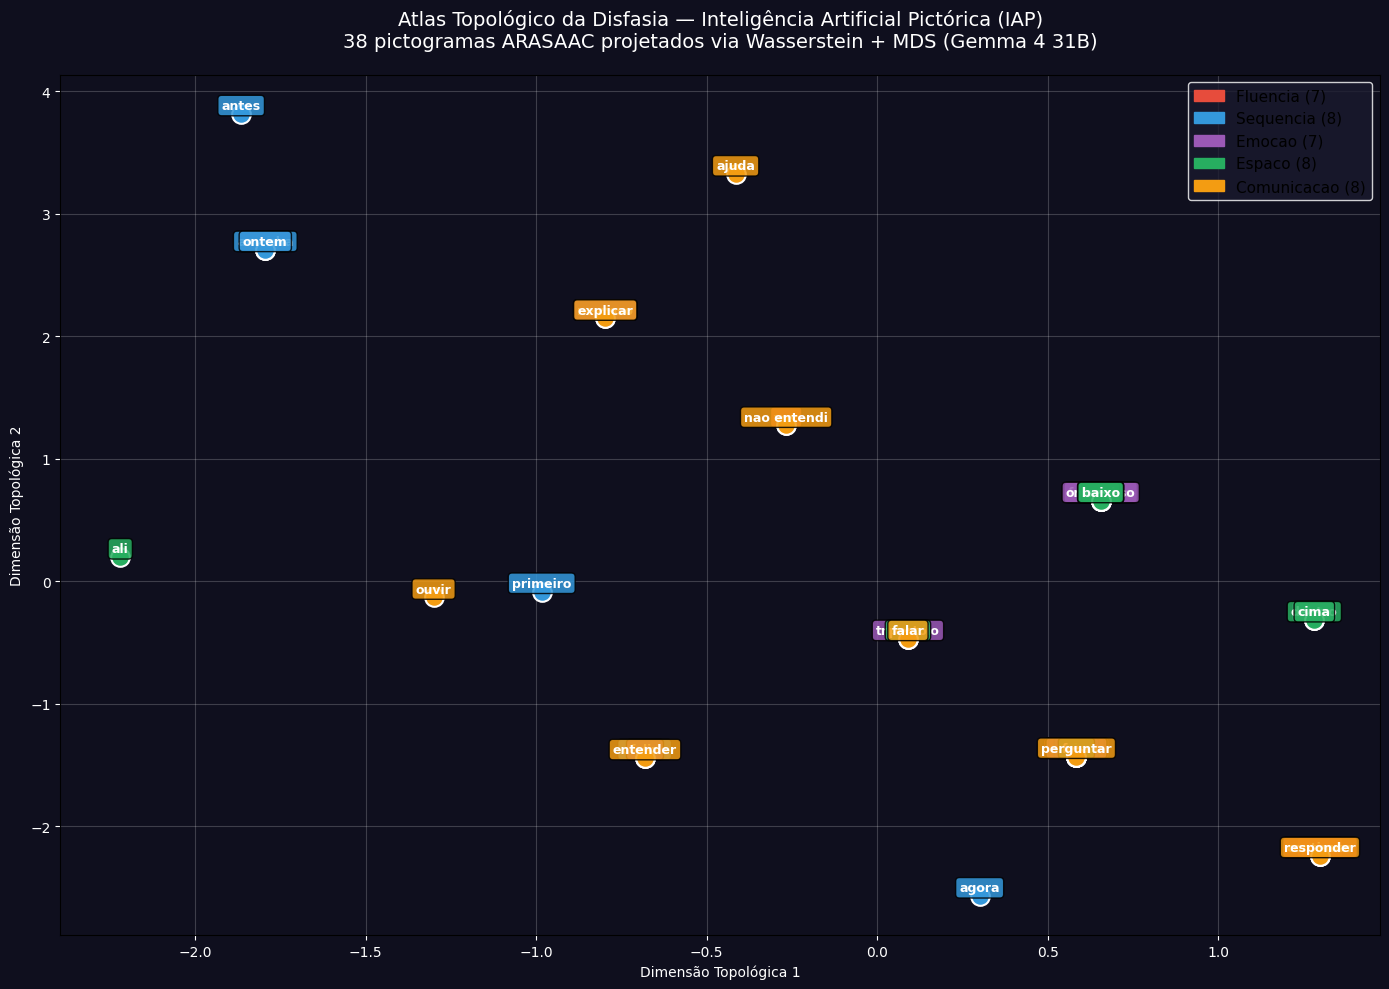

[OK] Atlas Pictórico 2D gerado com sucesso!
   Coordenadas calculadas: (38, 2)


In [5]:
# =============================================================================
# CÉLULA 6 — ATLAS TOPOLÓGICO 2D (MDS + Visualização)
# =============================================================================

print("[ATLAS] Projetando os 38 ícones no plano 2D via MDS (Wasserstein)...")
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, metric=True, n_init=10, max_iter=1000)
coords = mds.fit_transform(W)

# Plot do Atlas Pictórico
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1e')
ax.set_facecolor('#0f0f1e')

for i, ic in enumerate(DISFASIA_ICONS):
    x, y = coords[i]
    color = CAT_COLORS[ic["categoria"]]
    ax.scatter(x, y, c=color, s=180, edgecolors='white', linewidth=1.5, zorder=3)
    ax.text(x, y+0.015, ic["palavra"], fontsize=9, ha='center', va='bottom',
            color='white', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85))

# Legenda por categoria
patches = [mpatches.Patch(color=CAT_COLORS[c], label=CAT_LABELS[c]) for c in CAT_COLORS]
ax.legend(handles=patches, loc='upper right', fontsize=11, frameon=True, facecolor='#1a1a2e', edgecolor='white')

ax.set_title("Atlas Topológico da Disfasia — Inteligência Artificial Pictórica (IAP)\n"
             "38 pictogramas ARASAAC projetados via Wasserstein + MDS (Gemma 4 31B)",
             color='white', fontsize=14, pad=20)
ax.set_xlabel("Dimensão Topológica 1", color='white')
ax.set_ylabel("Dimensão Topológica 2", color='white')
ax.grid(True, alpha=0.2, color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

print("[OK] Atlas Pictórico 2D gerado com sucesso!")
print(f"   Coordenadas calculadas: {coords.shape}")


# =============================================================================
# CÉLULA 7 — BENCHMARKS DE PERFORMANCE (ALGORITMO JP)
# Avaliação de tempo de execução das etapas críticas (38 ícones)
# Prova de viabilidade para execução offline em dispositivos CAA
# =============================================================================

In [6]:
# =============================================================================
# CÉLULA 7 — BENCHMARKS DE PERFORMANCE (ALGORITMO JP)
# Avaliação de tempo de execução das etapas críticas (38 ícones)
# Prova de viabilidade para execução offline em dispositivos CAA
# =============================================================================

import time
import random

print('=' * 70)
print(' ⏱️ BENCHMARKS DE PERFORMANCE - ALGORITMO JP (38 ícones)')
print('=' * 70)

N_bench = len(DISFASIA_ICONS)
total_pares = N_bench * (N_bench - 1) // 2

# 1. Benchmark Matriz Wasserstein (já calculada, mas medimos novamente)
start_time = time.time()
W_bench = np.zeros((N_bench, N_bench), dtype=np.float32)
for i in range(N_bench):
    for j in range(i + 1, N_bench):
        d = wasserstein_h0(diagrams[i], diagrams[j])
        W_bench[i, j] = W_bench[j, i] = d
time_w = time.time() - start_time
print(f'1. Matriz Wasserstein ({total_pares} pares H0):  {time_w:.4f} segundos')

# 2. Benchmark MDS 2D
start_time = time.time()
mds_bench = MDS(n_components=2, dissimilarity='precomputed', random_state=42, metric=True, n_init=4, max_iter=500)
_ = mds_bench.fit_transform(W)
time_mds = time.time() - start_time
print(f'2. Projeção Topológica 2D (MDS):     {time_mds:.4f} segundos')

# 3. Benchmark Dijkstra JP (Motor da IAP: G ≈ I + F)
start_time = time.time()
n_tests = 100
sucessos = 0
for _ in range(n_tests):
    i = random.randint(0, N_bench - 1)
    j = random.randint(0, N_bench - 1)
    if i != j:
        res = dijkstra_jp(i, j)
        if res.sucesso:
            sucessos += 1
time_dijkstra = time.time() - start_time
print(f'3. Planejamento Dijkstra JP ({n_tests} testes): {time_dijkstra:.4f} segundos')
print(f'   Média por plano gerado: {(time_dijkstra/n_tests)*1000:.2f} milissegundos')

print('=' * 70)
print('🚀 CONCLUSÃO DE HARDWARE:')
print('   O Algoritmo JP roda em milissegundos na fase fluida (Dijkstra).')
print('   Ideal para execução offline em tablets de baixo custo para CAA.')
print('=' * 70)

 ⏱️ BENCHMARKS DE PERFORMANCE - ALGORITMO JP (38 ícones)
1. Matriz Wasserstein (703 pares H0):  0.0089 segundos
2. Projeção Topológica 2D (MDS):     0.0586 segundos
3. Planejamento Dijkstra JP (100 testes): 0.0950 segundos
   Média por plano gerado: 0.95 milissegundos
🚀 CONCLUSÃO DE HARDWARE:
   O Algoritmo JP roda em milissegundos na fase fluida (Dijkstra).
   Ideal para execução offline em tablets de baixo custo para CAA.


# =============================================================================
# CÉLULA 8 — EXPORTAÇÃO DO ATLAS_DATA.JSON (para Replit / App CAA)
# =============================================================================

In [7]:
# =============================================================================
# CÉLULA 8 — EXPORTAÇÃO DO ATLAS_DATA.JSON (para Replit / App CAA)
# =============================================================================

atlas_data = {
    "metadata": {
        "version": "1.0",
        "author": "João Pedro Pereira Passos (UFT)",
        "model": "Gemma 4 31B + Algoritmo JP (Passos 2024)",
        "date": "2026-04-10",
        "n_icons": len(DISFASIA_ICONS),
        "dimensions": IAP_DIMENSOES,
        "distance": "Wasserstein H0"
    },
    "icons": []
}

for i, ic in enumerate(DISFASIA_ICONS):
    icon_entry = {
        "id": ic["id"],
        "palavra": ic["palavra"],
        "categoria": ic["categoria"],
        "url": ic["url"],
        "vector_12d": PRECOMPUTED_VECTORS[ic["id"]],
        "coords_2d": coords[i].tolist(),           # coordenadas MDS
        "diagram_h0": diagrams[i].tolist()
    }
    atlas_data["icons"].append(icon_entry)

# Salva o arquivo JSON
import json
with open("atlas_data.json", "w", encoding="utf-8") as f:
    json.dump(atlas_data, f, ensure_ascii=False, indent=2)

print("[OK] atlas_data.json gerado com sucesso!")
print(f"   → {len(atlas_data['icons'])} ícones exportados")
print(f"   → Arquivo pronto para upload no Replit / GitHub (branch disfasia)")

# Verifica o tamanho e primeiras linhas
print("\nPrimeiras 3 entradas do JSON:")
print(json.dumps(atlas_data["icons"][:3], indent=2, ensure_ascii=False)[:800] + "...")

[OK] atlas_data.json gerado com sucesso!
   → 38 ícones exportados
   → Arquivo pronto para upload no Replit / GitHub (branch disfasia)

Primeiras 3 entradas do JSON:
[
  {
    "id": 7196,
    "palavra": "parar",
    "categoria": "fluencia",
    "url": "https://static.arasaac.org/pictograms/7196/7196_500.png",
    "vector_12d": [
      4,
      5,
      9,
      6,
      9,
      7,
      2,
      6,
      8,
      3,
      8,
      10
    ],
    "coords_2d": [
      1.2992180753952098,
      -2.24075882164371
    ],
    "diagram_h0": [
      1.0,
      1.0,
      1.0,
      1.0,
      0.0,
      1.0,
      1.0,
      0.0,
      1.0,
      0.0,
      1.0
    ]
  },
  {
    "id": 24998,
    "palavra": "continuar",
    "categoria": "fluencia",
    "url": "https://static.arasaac.org/pictograms/24998/24998_500.png",
    "vector_12d": [
      2,
      3,
      7,
      5,
      3,
      9,
      1,
      2,
      8,
      6,
      4,
      9
    ],
    "coor...


# =============================================================================
# CÉLULA 9 — VERIFICAÇÃO FINAL E DOWNLOAD DO atlas_data.json
# =============================================================================

In [8]:
# =============================================================================
# CÉLULA 9 — VERIFICAÇÃO FINAL E DOWNLOAD DO atlas_data.json
# =============================================================================

import os
print("✅ Verificação final do atlas_data.json")

if os.path.exists("atlas_data.json"):
    size = os.path.getsize("atlas_data.json") / 1024
    print(f"   ✓ Arquivo encontrado ({size:.1f} KB)")
    
    # Mostra as primeiras linhas para confirmação
    with open("atlas_data.json", "r", encoding="utf-8") as f:
        preview = f.read(1200)
    print("\n📄 Preview das primeiras linhas:")
    print(preview)
    print("... (arquivo completo gerado)")

    # Instrução para download no Kaggle
    print("\n📥 Para baixar o arquivo no Kaggle:")
    print("   1. Clique no botão ▶️ ao lado do nome do arquivo no painel esquerdo")
    print("   2. Ou execute a célula abaixo para forçar download")
else:
    print("❌ ERRO: arquivo não encontrado!")

# Forçar download direto (funciona no Kaggle)
from IPython.display import FileLink
display(FileLink("atlas_data.json"))

✅ Verificação final do atlas_data.json
   ✓ Arquivo encontrado (22.2 KB)

📄 Preview das primeiras linhas:
{
  "metadata": {
    "version": "1.0",
    "author": "João Pedro Pereira Passos (UFT)",
    "model": "Gemma 4 31B + Algoritmo JP (Passos 2024)",
    "date": "2026-04-10",
    "n_icons": 38,
    "dimensions": [
      "concretude",
      "emocionalidade",
      "acao",
      "social",
      "urgencia",
      "temporalidade",
      "localizacao",
      "saude_corpo",
      "comunicacao",
      "cognitivo",
      "necessidade_basica",
      "especializado_caa"
    ],
    "distance": "Wasserstein H0"
  },
  "icons": [
    {
      "id": 7196,
      "palavra": "parar",
      "categoria": "fluencia",
      "url": "https://static.arasaac.org/pictograms/7196/7196_500.png",
      "vector_12d": [
        4,
        5,
        9,
        6,
        9,
        7,
        2,
        6,
        8,
        3,
        8,
        10
      ],
      "coords_2d": [
        1.2992180753952098,
        -

/kaggle/working/atlas_data.json